# Day 6 — Smartphone Usage & Addiction EDA

Датасет: `Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv` — 7500 пользователей, 16 признаков.

---

## 📌 Выводы по дашборду

**1. Экранное время по уровню зависимости (KDE)**
Чёткий рост: Mild ≈ 5.5 ч/день → Moderate ≈ 8.4 ч → Severe ≈ 8.6 ч. Главный скачок — между Mild и Moderate (+3 ч), дальше плато (Moderate ≈ Severe). Кривая Mild стоит отдельно слева — «лёгкие» пользователи хорошо отделимы по экранному времени.

**2. Часы в соцсетях (violin)**
Та же лестница: 2.3 → 3.6 → 3.8 ч. Зависимые сидят в соцсетях почти в **1.7 раза** дольше, чем Mild. Разброс у Severe шире — поведение менее однородное.

**3. Уровни зависимости по полу (countplot)**
Распределение почти идентично у Male / Female / Other (Severe 35–37 %, Moderate 41–44 %, Mild ≈ 20 %). **Пол не влияет** на уровень зависимости.

**4. Корреляции (heatmap)**
Сильнее всего связаны `daily_screen_time` ↔ `weekend_screen_time` (**0.96** — почти дубликаты). С меткой `addicted_label`: экранное время (0.58), выходные (0.56), соцсети (0.41). `sleep_hours` ≈ 0 — сон ни с чем не связан.

**Итог:** зависимость определяется прежде всего экранным временем и соцсетями, а не полом, возрастом или сном. Данные синтетические — связи заложены только в «ожидаемых» парах.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# единый красивый стиль для всех графиков
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.edgecolor": "#cccccc",
    "grid.alpha": 0.3,
})

# семантическая палитра по уровню зависимости: зелёный → жёлтый → красный
LEVELS = ["Mild", "Moderate", "Severe"]
LEVEL_PAL = {"Mild": "#2a9d8f", "Moderate": "#e9c46a", "Severe": "#e76f51"}

df = pd.read_csv("data/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [64]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [65]:
df["stress_level"].unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [66]:
df["addiction_level"].unique()

array([nan, 'Mild', 'Moderate', 'Severe'], dtype=object)

In [67]:
df['daily_screen_time_hours'].describe().round(0)

count    7500.0
mean        7.0
std         3.0
min         3.0
25%         5.0
50%         8.0
75%        10.0
max        12.0
Name: daily_screen_time_hours, dtype: float64

In [68]:
print('среднее :', round(df["addicted_label"].mean()))
print('медиана :', round(df["addicted_label"].median()))
print('отношение среднее/медиана:', round(df["addicted_label"].mean()/df["addicted_label"].median(), 2))

среднее : 1
медиана : 1
отношение среднее/медиана: 0.71


## Квартили daily_screen_time_hours

Q1=5.22  медиана=7.53  Q3=9.81  IQR=4.59


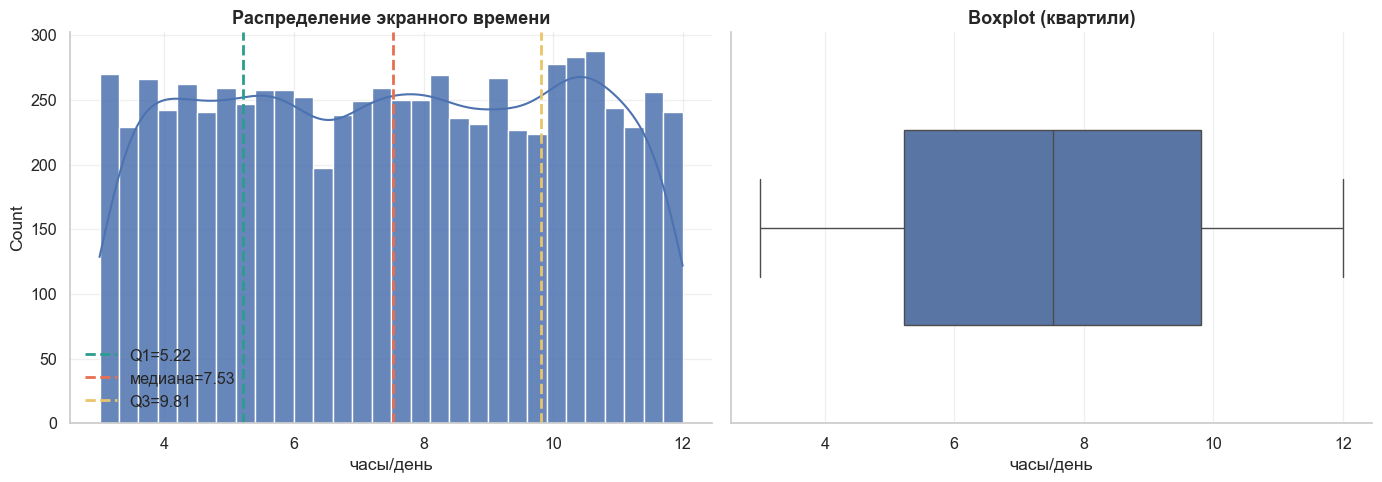

In [69]:
s = df["daily_screen_time_hours"]
q1, q2, q3 = s.quantile([.25, .5, .75])
print(f"Q1={q1:.2f}  медиана={q2:.2f}  Q3={q3:.2f}  IQR={q3-q1:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(s, bins=30, kde=True, color="#4c72b0", edgecolor="white", alpha=.85, ax=ax[0])
for q, c, l in [(q1, "#2a9d8f", "Q1"), (q2, "#e76f51", "медиана"), (q3, "#e9c46a", "Q3")]:
    ax[0].axvline(q, color=c, ls="--", lw=2, label=f"{l}={q:.2f}")
ax[0].set_title("Распределение экранного времени")
ax[0].set_xlabel("часы/день")
ax[0].legend(frameon=False)

sns.boxplot(x=s, color="#4c72b0", width=.5, fliersize=3, ax=ax[1])
ax[1].set_title("Boxplot (квартили)")
ax[1].set_xlabel("часы/день")
sns.despine()
plt.tight_layout()
plt.show()

## Проверка выбросов (IQR) по всем числовым колонкам

In [70]:
num = df.select_dtypes("number").drop(columns=["addicted_label"])

for c in num.columns:
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n = ((df[c] < lo) | (df[c] > hi)).sum()
    print(f"{c:<28} выбросов: {n}")

age                          выбросов: 0
daily_screen_time_hours      выбросов: 0
social_media_hours           выбросов: 0
gaming_hours                 выбросов: 0
work_study_hours             выбросов: 0
sleep_hours                  выбросов: 0
notifications_per_day        выбросов: 0
app_opens_per_day            выбросов: 0
weekend_screen_time          выбросов: 0


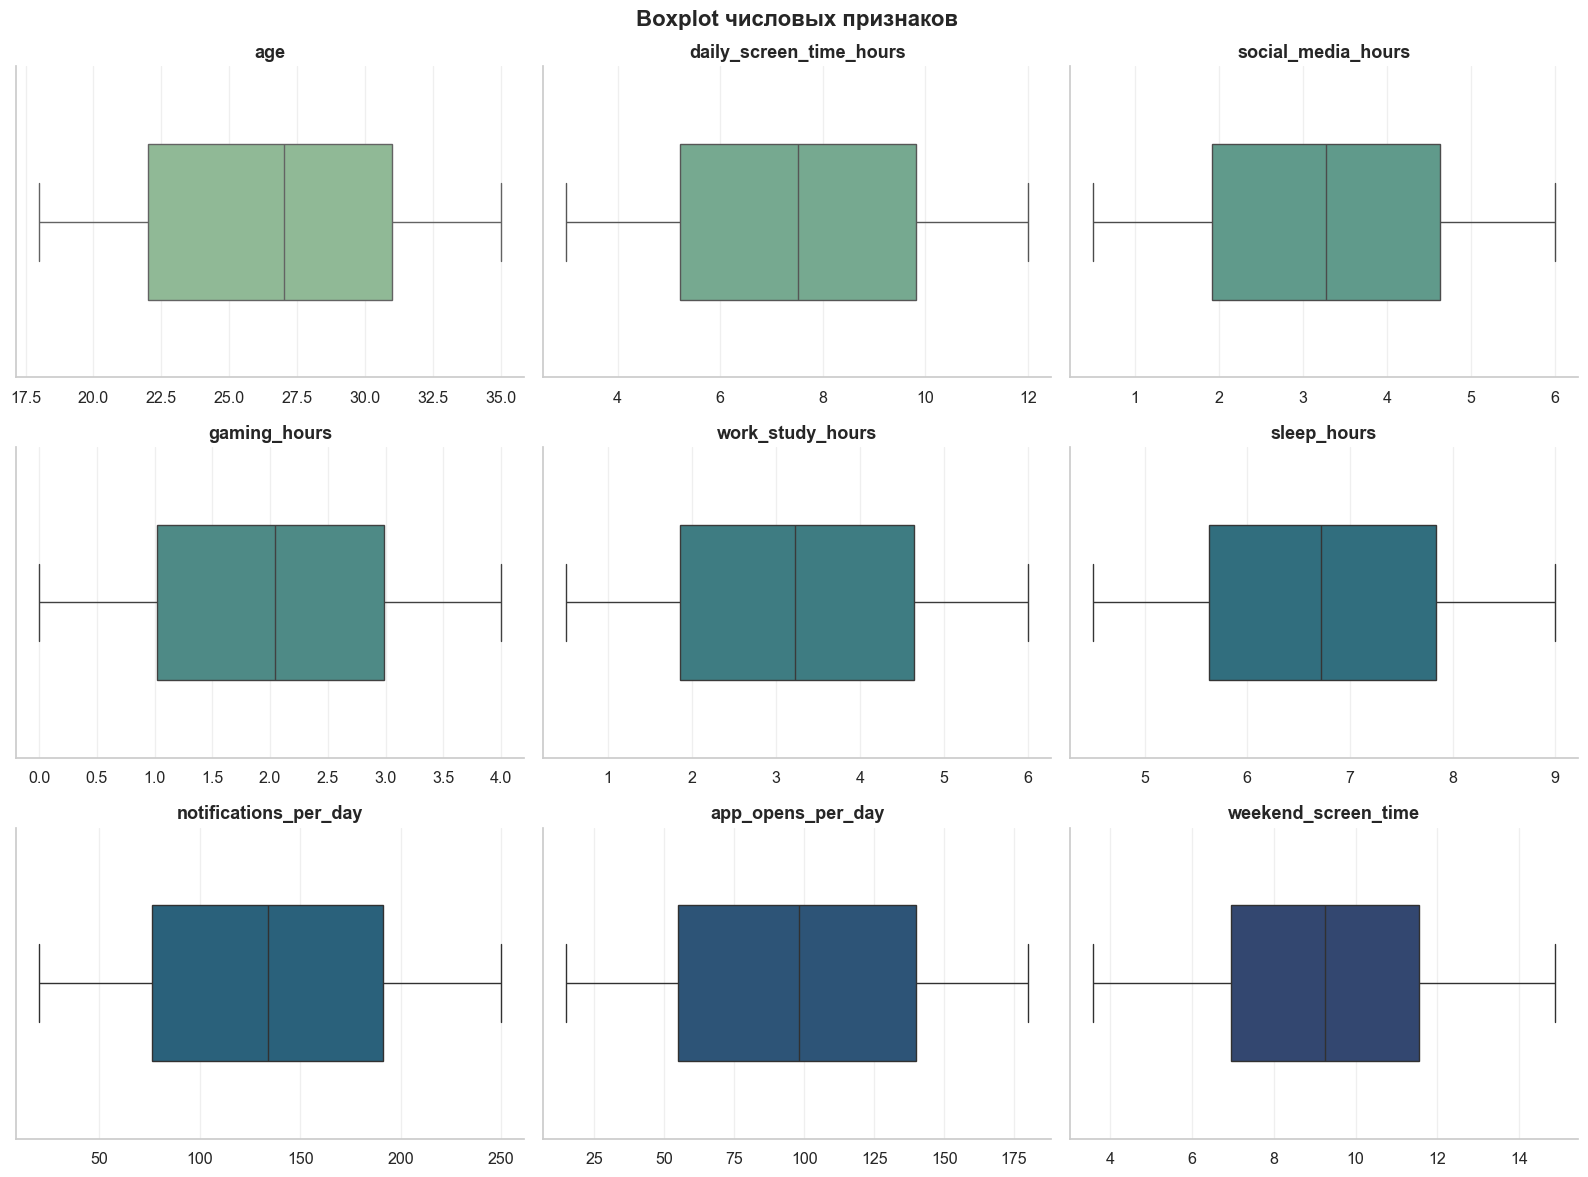

In [71]:
n = len(num.columns)
rows = (n + 2) // 3
pal = sns.color_palette("crest", n)

fig, axes = plt.subplots(rows, 3, figsize=(16, 4*rows))
for ax, c, col in zip(axes.flat, num.columns, pal):
    sns.boxplot(x=df[c], color=col, width=.5, fliersize=3, ax=ax)
    ax.set_title(c)
    ax.set_xlabel("")
for ax in axes.flat[n:]:
    ax.set_visible(False)
fig.suptitle("Boxplot числовых признаков", fontsize=16, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

## Связь sleep_hours с остальными признаками

Проверяем, влияет ли использование телефона на сон. Спойлер: в этих данных связь почти нулевая (все |r| < 0.04).

Корреляция sleep_hours с числовыми признаками:
work_study_hours          -0.027
age                       -0.007
gaming_hours              -0.003
app_opens_per_day          0.006
social_media_hours         0.006
notifications_per_day      0.016
weekend_screen_time        0.019
daily_screen_time_hours    0.019
addicted_label             0.035
Name: sleep_hours, dtype: float64


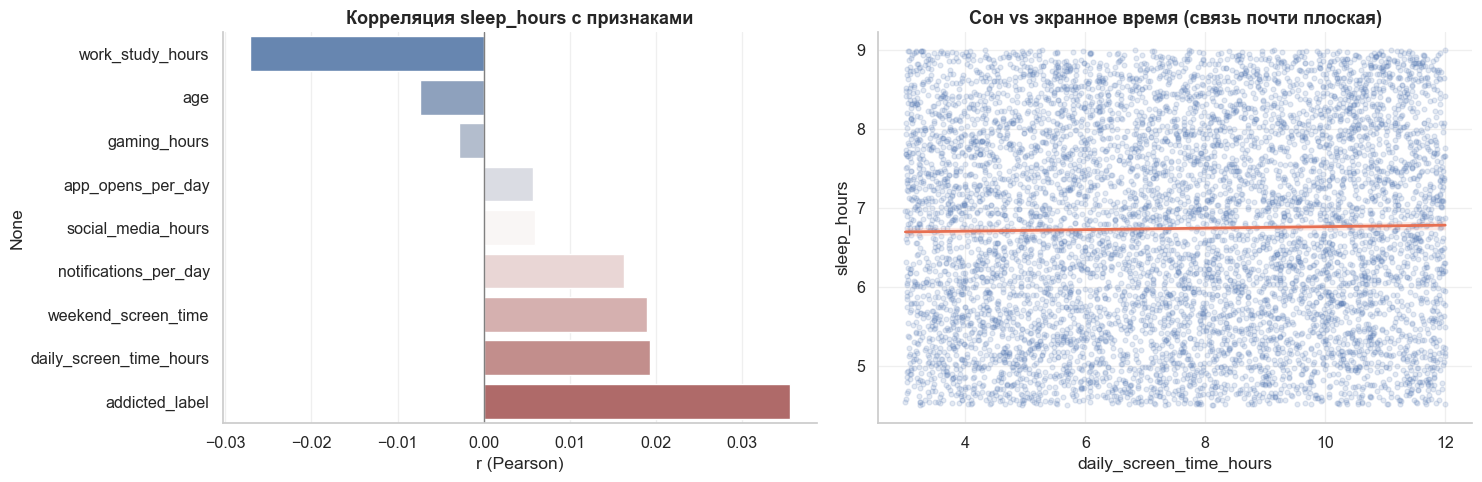

In [72]:
num = df.select_dtypes("number")
sleep_corr = num.corr()["sleep_hours"].drop("sleep_hours").sort_values()
print("Корреляция sleep_hours с числовыми признаками:")
print(sleep_corr.round(3))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=sleep_corr.values, y=sleep_corr.index,
            hue=sleep_corr.index, legend=False, palette="vlag", ax=ax[0])
ax[0].axvline(0, color="gray", lw=1)
ax[0].set_title("Корреляция sleep_hours с признаками")
ax[0].set_xlabel("r (Pearson)")

sns.regplot(data=df, x="daily_screen_time_hours", y="sleep_hours",
            scatter_kws={"alpha": .15, "s": 12, "color": "#4c72b0"},
            line_kws={"color": "#e76f51", "lw": 2}, ax=ax[1])
ax[1].set_title("Сон vs экранное время (связь почти плоская)")
sns.despine()
plt.tight_layout()
plt.show()

## 🎨 Визуальный обзор (дашборд)

Четыре графика на одном полотне: распределение экранного времени, соцсети, разбивка по полу и корреляции.

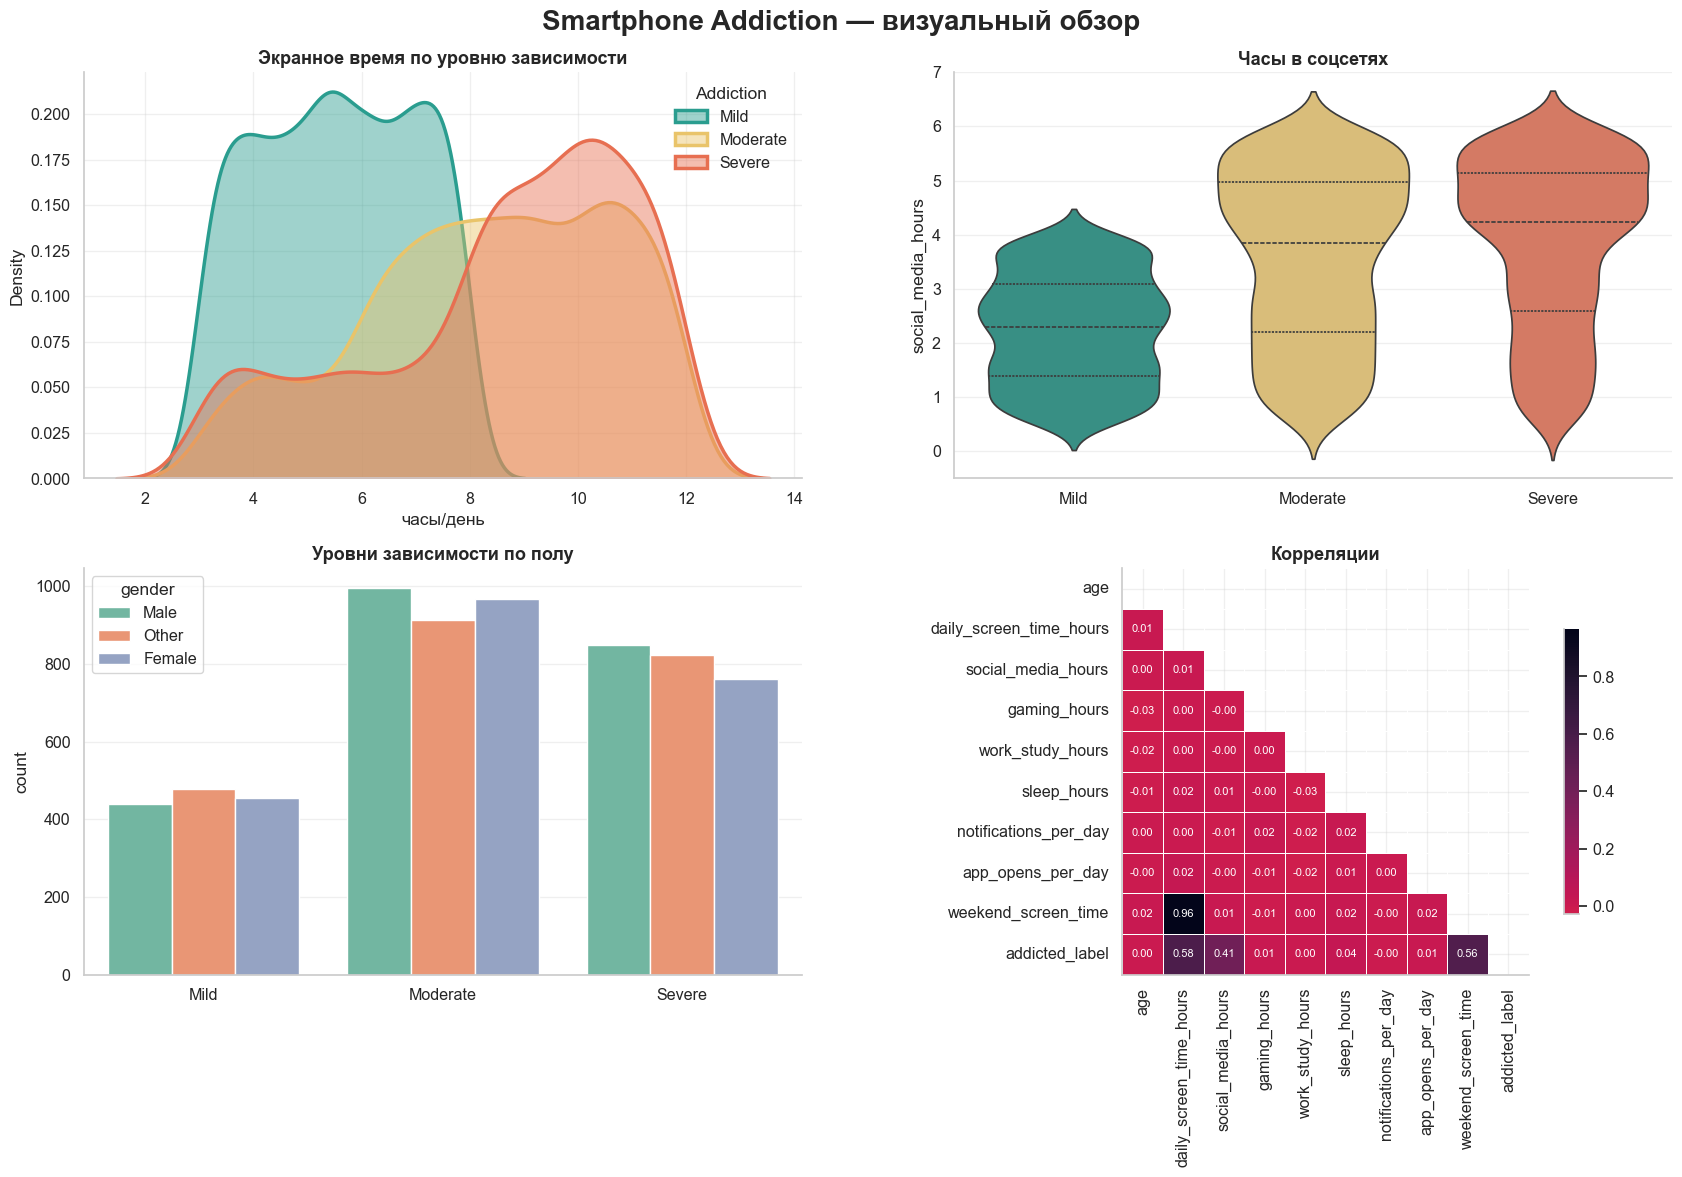

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(17, 12))
fig.suptitle("Smartphone Addiction — визуальный обзор", fontsize=20, fontweight="bold")

# 1) Экранное время по уровню зависимости (KDE с заливкой)
for lvl in LEVELS:
    sns.kdeplot(df.loc[df["addiction_level"] == lvl, "daily_screen_time_hours"],
                fill=True, alpha=.45, lw=2.5, label=lvl, color=LEVEL_PAL[lvl], ax=axes[0, 0])
axes[0, 0].set_title("Экранное время по уровню зависимости")
axes[0, 0].set_xlabel("часы/день")
axes[0, 0].legend(title="Addiction", frameon=False)

# 2) Часы в соцсетях (violin)
sns.violinplot(data=df, x="addiction_level", y="social_media_hours", order=LEVELS,
               hue="addiction_level", palette=LEVEL_PAL, legend=False,
               inner="quartile", ax=axes[0, 1])
axes[0, 1].set_title("Часы в соцсетях")
axes[0, 1].set_xlabel("")

# 3) Уровни зависимости по полу
sns.countplot(data=df, x="addiction_level", order=LEVELS, hue="gender",
              palette="Set2", ax=axes[1, 0])
axes[1, 0].set_title("Уровни зависимости по полу")
axes[1, 0].set_xlabel("")

# 4) Корреляции (нижний треугольник)
corr = df.select_dtypes("number").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="rocket_r", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .7},
            annot_kws={"size": 8}, ax=axes[1, 1])
axes[1, 1].set_title("Корреляции")

sns.despine()
plt.tight_layout()
plt.show()

## Распределение addiction_level

Сколько пользователей в каждом классе зависимости (Mild / Moderate / Severe). Учитываем, что 819 значений пропущено.

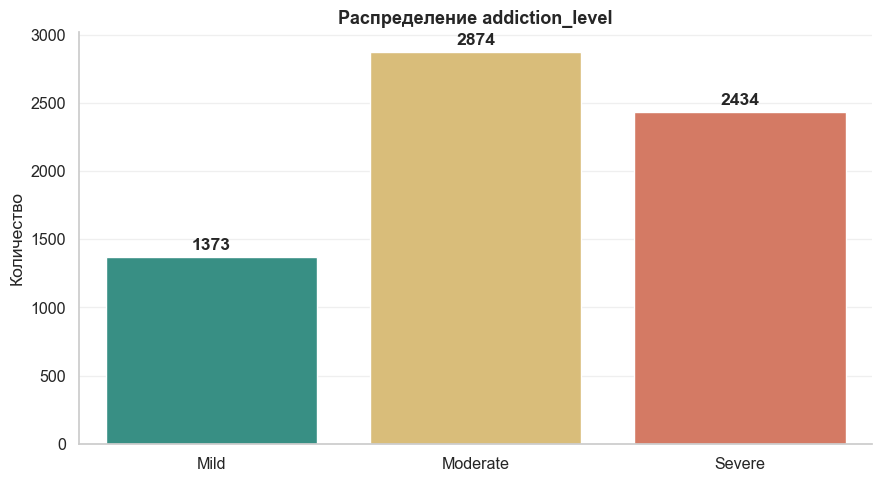

Пропусков (NaN): 819


addiction_level
Moderate    2874
Severe      2434
Mild        1373
NaN          819
Name: count, dtype: int64

In [74]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df, x="addiction_level", order=LEVELS,
                   hue="addiction_level", palette=LEVEL_PAL, legend=False)
for c in ax.containers:
    ax.bar_label(c, padding=3, fontweight="bold")
plt.title("Распределение addiction_level")
plt.ylabel("Количество")
plt.xlabel("")
sns.despine()
plt.tight_layout()
plt.show()

print("Пропусков (NaN):", df["addiction_level"].isna().sum())
df["addiction_level"].value_counts(dropna=False)

## Проверка пропусков (неуказанная информация)

Где в данных есть NaN. Карта пропусков + доля пропущенного по колонкам.

In [ ]:
from matplotlib.colors import ListedColormap

miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
total = df.isna().sum().sum()
print("Пропуски по колонкам:")
print(miss.to_string() if len(miss) else "нет пропусков")
print(f"\nВсего пропусков: {total} ({total/df.size*100:.2f}% всех ячеек)")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# карта пропусков (красный = NaN)
sns.heatmap(df.isna(), cbar=False,
            cmap=ListedColormap(["#dfe6e9", "#e76f51"]), ax=ax[0])
ax[0].set_title("Карта пропусков (красный = NaN)")
ax[0].set_xlabel("колонки")
ax[0].set_ylabel("строки")

# доля пропусков по колонкам
if len(miss):
    miss_pct = miss / len(df) * 100
    bars = sns.barplot(x=miss_pct.values, y=miss_pct.index, color="#e76f51", ax=ax[1])
    for c in bars.containers:
        bars.bar_label(c, fmt="%.1f%%", padding=3, fontweight="bold")
    ax[1].set_title("% пропусков по колонкам")
    ax[1].set_xlabel("% NaN")
sns.despine()
plt.tight_layout()
plt.show()

## Зависимость между стрессом и addiction_level

Обе колонки категориальные → **Cramér's V** (0 = нет связи, 1 = полная) + χ² на значимость.

Cramér's V = 0.0096   |   p-value = 0.871
Вывод: связи НЕТ (p > 0.05)


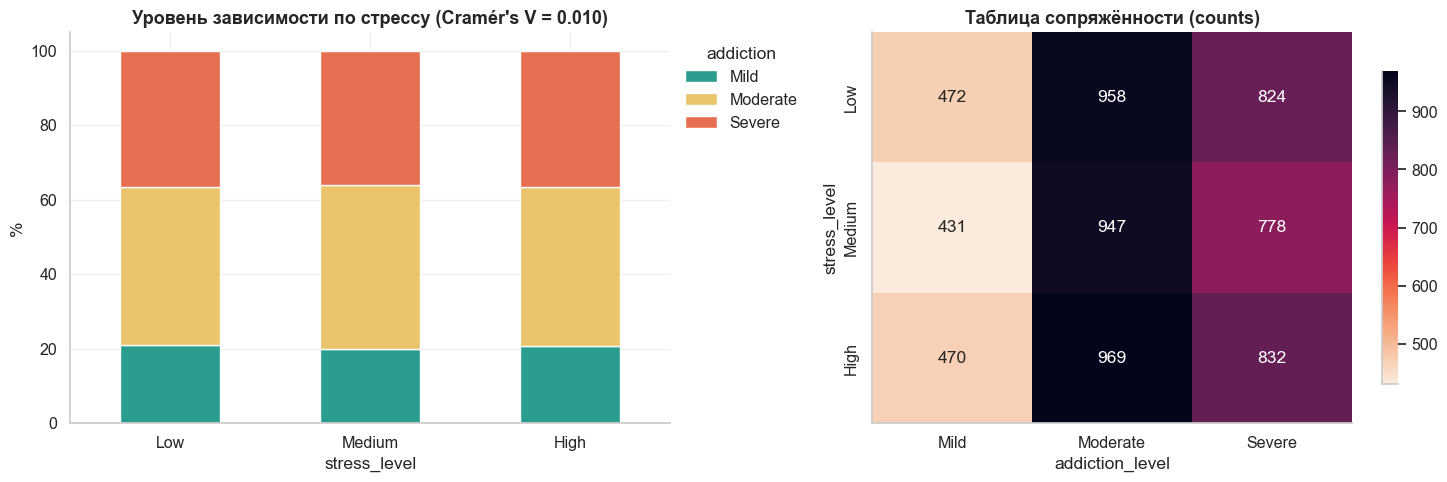

In [78]:
from scipy.stats import chi2_contingency

stress_order = ["Low", "Medium", "High"]
d = df.dropna(subset=["addiction_level"])
ct = pd.crosstab(d["stress_level"], d["addiction_level"])[LEVELS].reindex(stress_order)

chi2, p, dof, _ = chi2_contingency(ct)
n = ct.sum().sum(); r, k = ct.shape
cramers_v = np.sqrt((chi2 / n) / min(k - 1, r - 1))
print(f"Cramér's V = {cramers_v:.4f}   |   p-value = {p:.3f}")
print("Вывод:", "связь есть" if p < 0.05 else "связи НЕТ (p > 0.05)")

norm = (pd.crosstab(d["stress_level"], d["addiction_level"], normalize="index")[LEVELS]
        .reindex(stress_order) * 100)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
norm.plot(kind="bar", stacked=True, color=[LEVEL_PAL[l] for l in LEVELS], ax=ax[0])
ax[0].set_title(f"Уровень зависимости по стрессу (Cramér's V = {cramers_v:.3f})")
ax[0].set_ylabel("%")
ax[0].set_xlabel("stress_level")
ax[0].tick_params(axis="x", rotation=0)
ax[0].legend(title="addiction", bbox_to_anchor=(1.0, 1.0), frameon=False)

sns.heatmap(ct, annot=True, fmt="d", cmap="rocket_r", cbar_kws={"shrink": .8}, ax=ax[1])
ax[1].set_title("Таблица сопряжённости (counts)")
sns.despine()
plt.tight_layout()
plt.show()

## Стандартизация notifications_per_day

`StandardScaler` (z-score): приводим к среднему 0 и σ 1. Форма распределения сохраняется, меняется только масштаб оси.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["notifications_per_day_scaled"] = scaler.fit_transform(df[["notifications_per_day"]])

print(f"До:    mean = {df['notifications_per_day'].mean():.2f}, std = {df['notifications_per_day'].std():.2f}")
print(f"После: mean = {df['notifications_per_day_scaled'].mean():.2f}, std = {df['notifications_per_day_scaled'].std():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["notifications_per_day"], bins=30, kde=True, color="#4c72b0", ax=ax[0])
ax[0].set_title("До стандартизации (исходный масштаб)")
ax[0].set_xlabel("уведомлений/день")

sns.histplot(df["notifications_per_day_scaled"], bins=30, kde=True, color="#2a9d8f", ax=ax[1])
ax[1].axvline(0, color="#e76f51", ls="--", lw=2, label="среднее = 0")
ax[1].set_title("После стандартизации (z-score)")
ax[1].set_xlabel("z (σ от среднего)")
ax[1].legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

df[["notifications_per_day", "notifications_per_day_scaled"]].head()

In [75]:
df["addicted_label"]

0       0
1       0
2       0
3       1
4       1
       ..
7495    1
7496    0
7497    1
7498    1
7499    1
Name: addicted_label, Length: 7500, dtype: int64

In [76]:
print('средняя зависимость:', round(df["addicted_label"].mean(), 2))
print('ответили:', df["addicted_label"].notna().sum(), '   молчат:', df["addicted_label"].isna().sum())

средняя зависимость: 0.71
ответили: 7500    молчат: 0


## Визуализация addicted_label (таргет)

Распределение бинарной метки зависимости: количество (bar) и доли (pie).

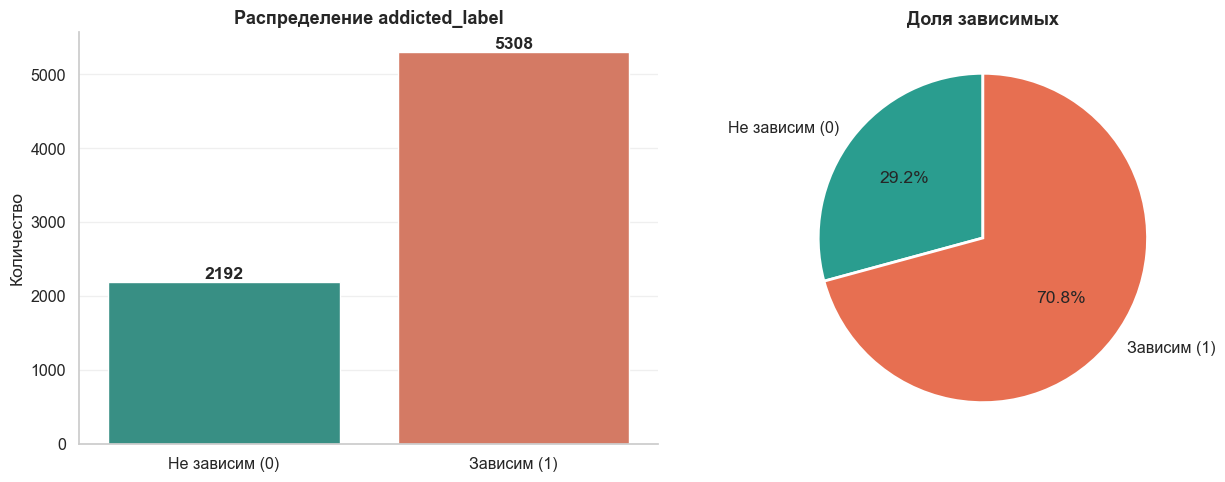

In [107]:
counts = df["addicted_label"].value_counts().sort_index()
labels = {0: "Не зависим (0)", 1: "Зависим (1)"}
names = [labels[i] for i in counts.index]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# bar с количеством
bars = sns.barplot(x=names, y=counts.values, hue=names, legend=False,
                   palette=["#2a9d8f", "#e76f51"], ax=ax[0])
for c in bars.containers:
    bars.bar_label(c, fontweight="bold")
ax[0].set_title("Распределение addicted_label")
ax[0].set_ylabel("Количество")

# pie с долями
ax[1].pie(counts.values, labels=names, autopct="%1.1f%%",
          colors=["#2a9d8f", "#e76f51"], startangle=90,
          wedgeprops={"edgecolor": "white", "linewidth": 2})
ax[1].set_title("Доля зависимых")

sns.despine()
plt.tight_layout()
plt.show()

## Корреляции внутри выборки Severe

Берём подвыборку `addiction_level == "Severe"` и считаем корреляции только внутри неё.

Размер выборки Severe: 2434


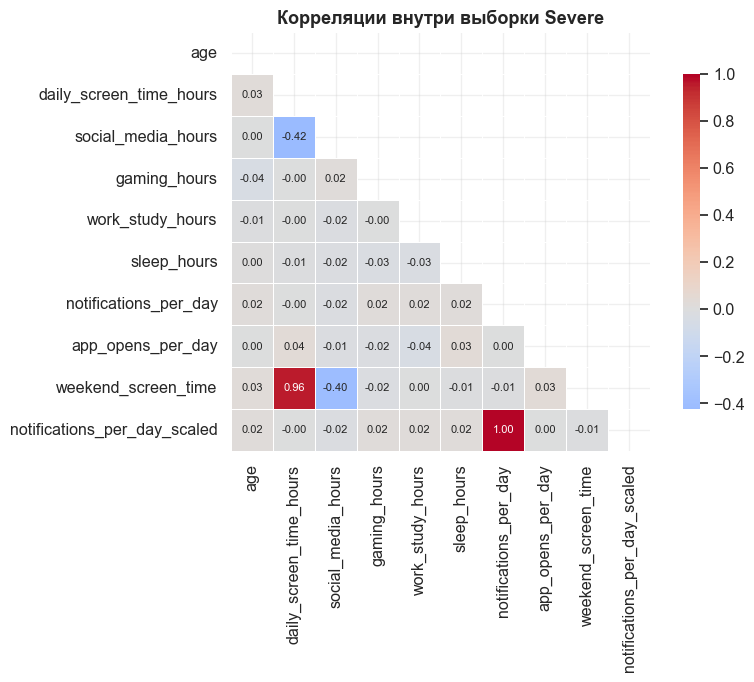

notifications_per_day    notifications_per_day_scaled    1.00
daily_screen_time_hours  weekend_screen_time             0.96
                         social_media_hours             -0.42
social_media_hours       weekend_screen_time            -0.40
work_study_hours         app_opens_per_day              -0.04
age                      gaming_hours                   -0.04
dtype: float64

In [108]:
sev = df[df["addiction_level"] == "Severe"]
print("Размер выборки Severe:", len(sev))

num_sev = sev.select_dtypes("number").drop(columns=["addicted_label"])
corr_sev = num_sev.corr()
mask = np.triu(np.ones_like(corr_sev, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(corr_sev, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, annot_kws={"size": 8})
plt.title("Корреляции внутри выборки Severe")
plt.tight_layout()
plt.show()

# топ пар по силе связи
(corr_sev.where(~np.eye(len(corr_sev), dtype=bool)).stack()
 .drop_duplicates().sort_values(key=abs, ascending=False).head(6).round(2))

## addiction_level через subplots

Один `plt.subplots(2, 2)` — четыре среза по уровню зависимости: распределение, экранное время, соцсети, разбивка по полу.

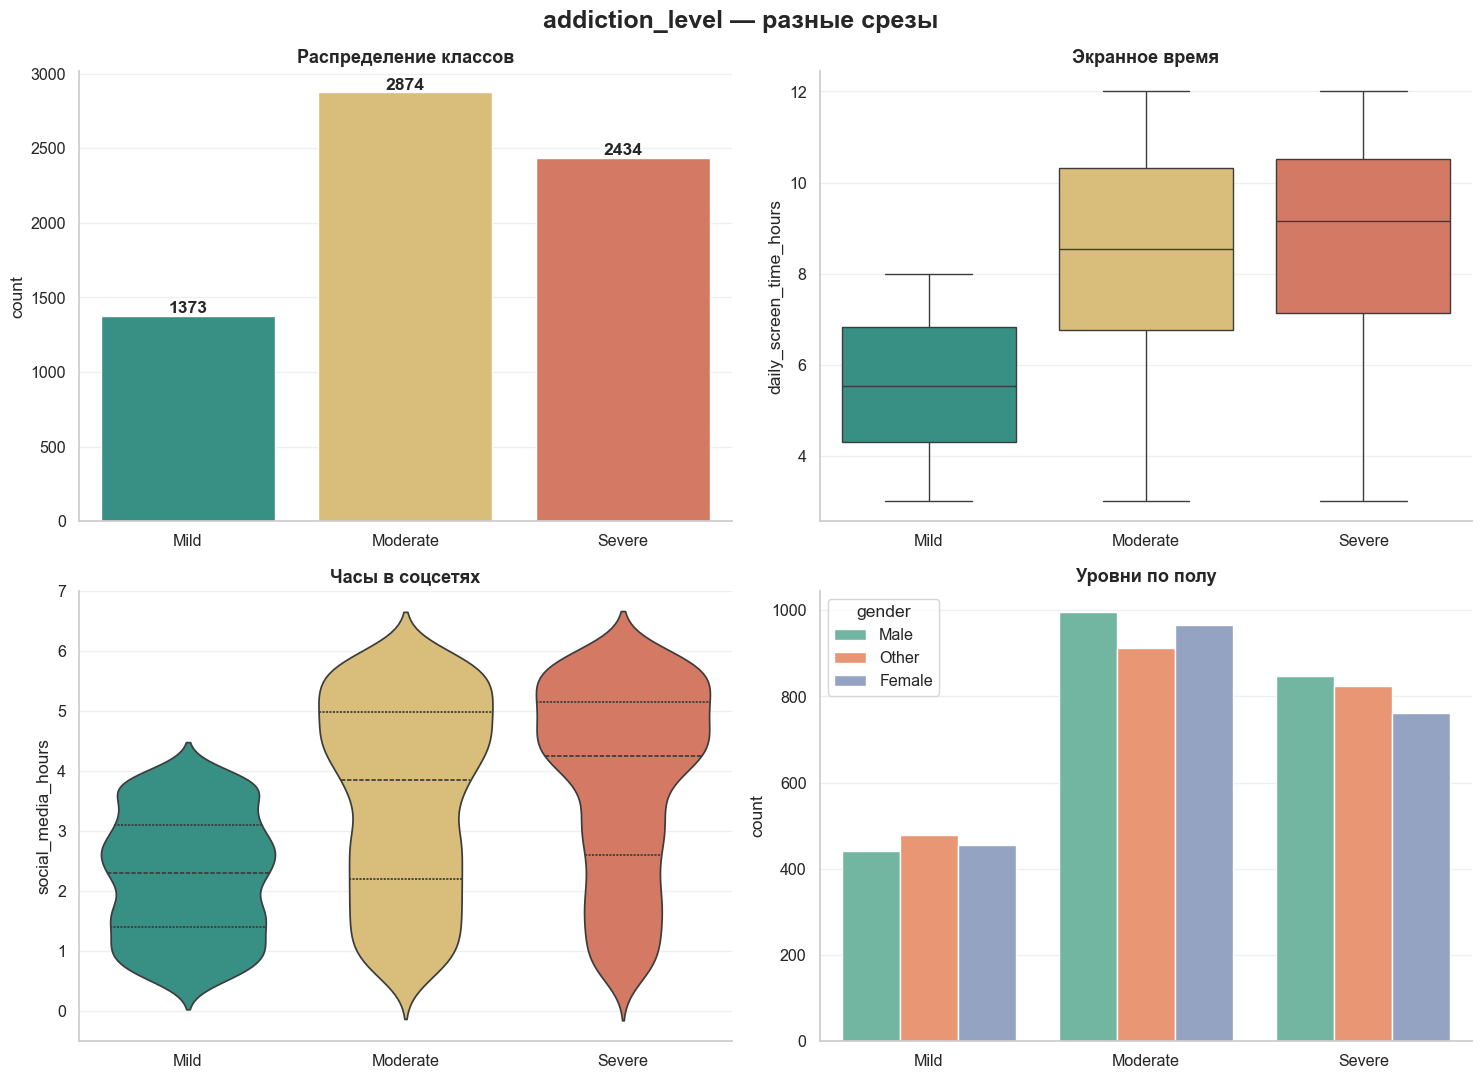

In [109]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("addiction_level — разные срезы", fontsize=18, fontweight="bold")

# 1) распределение
sns.countplot(data=df, x="addiction_level", order=LEVELS, hue="addiction_level",
              palette=LEVEL_PAL, legend=False, ax=axes[0, 0])
for c in axes[0, 0].containers:
    axes[0, 0].bar_label(c, fontweight="bold")
axes[0, 0].set_title("Распределение классов")
axes[0, 0].set_xlabel("")

# 2) экранное время по уровню
sns.boxplot(data=df, x="addiction_level", y="daily_screen_time_hours", order=LEVELS,
            hue="addiction_level", palette=LEVEL_PAL, legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Экранное время")
axes[0, 1].set_xlabel("")

# 3) соцсети по уровню
sns.violinplot(data=df, x="addiction_level", y="social_media_hours", order=LEVELS,
               hue="addiction_level", palette=LEVEL_PAL, legend=False,
               inner="quartile", ax=axes[1, 0])
axes[1, 0].set_title("Часы в соцсетях")
axes[1, 0].set_xlabel("")

# 4) уровни по полу
sns.countplot(data=df, x="addiction_level", order=LEVELS, hue="gender",
              palette="Set2", ax=axes[1, 1])
axes[1, 1].set_title("Уровни по полу")
axes[1, 1].set_xlabel("")

sns.despine()
plt.tight_layout()
plt.show()

## Три выборки на одном графике (scatter + hue)

Точечный график: все три уровня (Mild / Moderate / Severe) сразу, разделены цветом через `hue`.

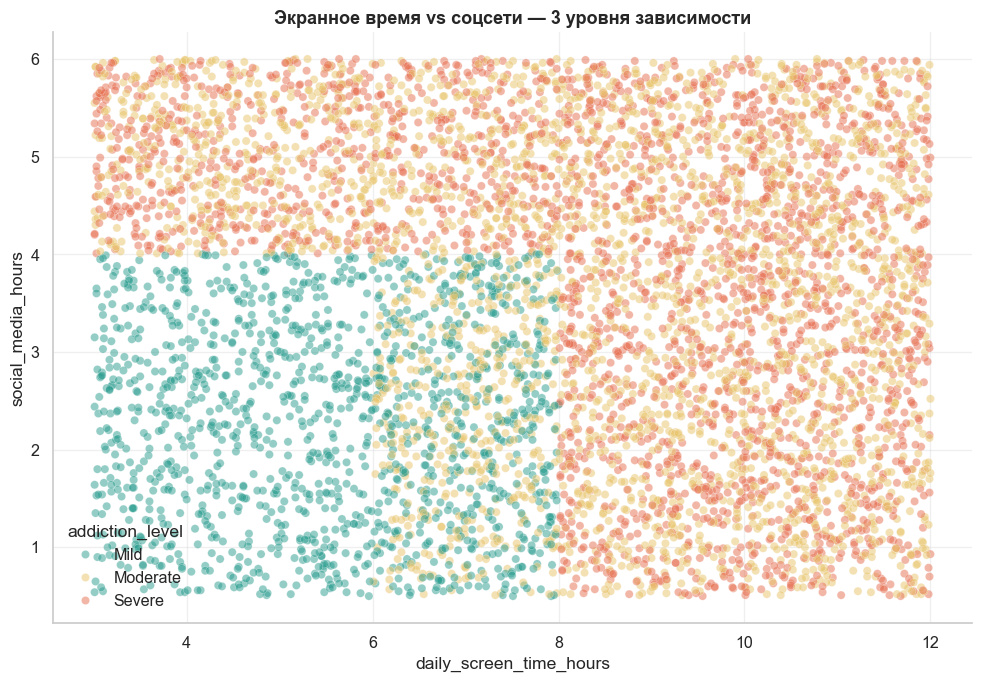

In [110]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="daily_screen_time_hours", y="social_media_hours",
                hue="addiction_level", hue_order=LEVELS, palette=LEVEL_PAL,
                alpha=0.5, s=35, edgecolor="white", linewidth=0.3)
plt.title("Экранное время vs соцсети — 3 уровня зависимости")
plt.xlabel("daily_screen_time_hours")
plt.ylabel("social_media_hours")
plt.legend(title="addiction_level", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## Почему внутри Severe r = −0.42 (эффект отбора)

По всем данным `daily_screen_time ↔ social_media` ≈ 0, но внутри Severe — **−0.42**.
Причина: фиксируя высокий общий уровень (Severe), мы создаём компромисс между видами активности — меньше соцсетей ⇒ больше другого экранного времени.

Корреляция screen_time ↔ social_media:  все данные = 0.01   |   Severe = -0.42


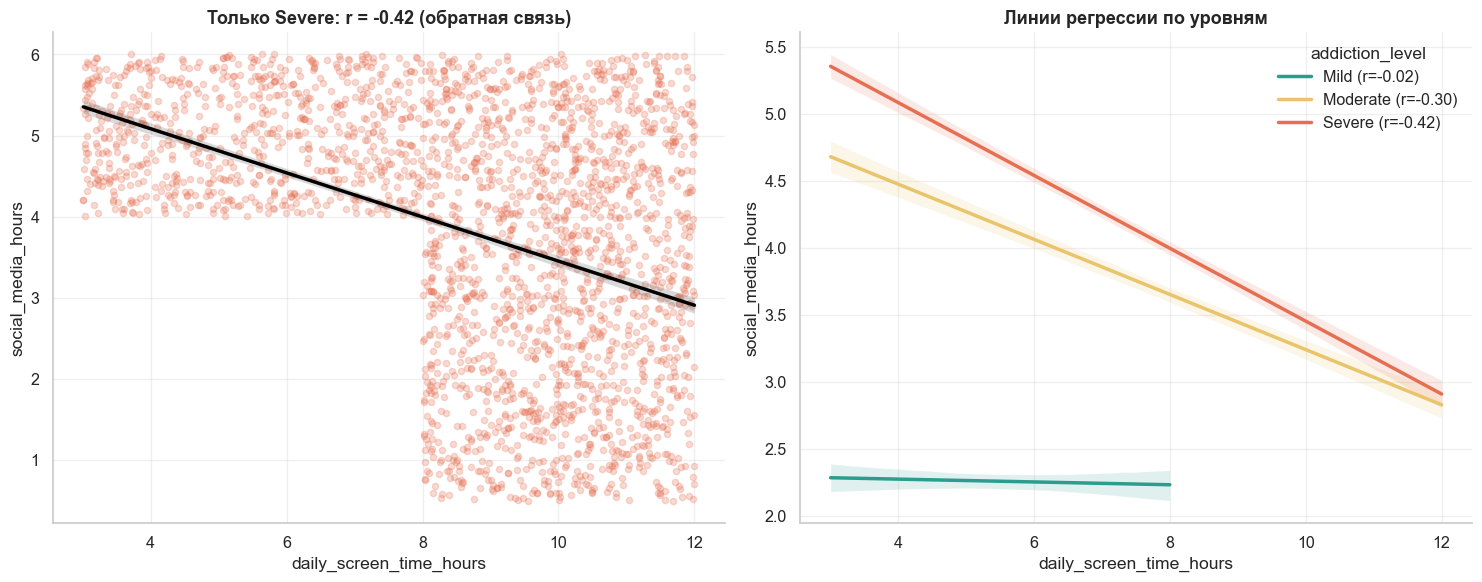

In [111]:
sev = df[df["addiction_level"] == "Severe"]
r_all = df["daily_screen_time_hours"].corr(df["social_media_hours"])
r_sev = sev["daily_screen_time_hours"].corr(sev["social_media_hours"])
print(f"Корреляция screen_time ↔ social_media:  все данные = {r_all:.2f}   |   Severe = {r_sev:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# слева: только Severe — видна отрицательная линия
sns.regplot(data=sev, x="daily_screen_time_hours", y="social_media_hours",
            scatter_kws={"alpha": .25, "s": 20, "color": "#e76f51"},
            line_kws={"color": "black", "lw": 2.5}, ax=ax[0])
ax[0].set_title(f"Только Severe: r = {r_sev:.2f} (обратная связь)")

# справа: линии регрессии по каждому уровню отдельно
for lvl in LEVELS:
    g = df[df["addiction_level"] == lvl]
    sns.regplot(data=g, x="daily_screen_time_hours", y="social_media_hours",
                scatter=False, label=f"{lvl} (r={g['daily_screen_time_hours'].corr(g['social_media_hours']):.2f})",
                line_kws={"color": LEVEL_PAL[lvl], "lw": 2.5}, ax=ax[1])
ax[1].set_title("Линии регрессии по уровням")
ax[1].legend(title="addiction_level", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

## Выборка Severe — обзор

Распределения ключевых признаков в группе Severe по сравнению со всеми данными (KDE-наложение).

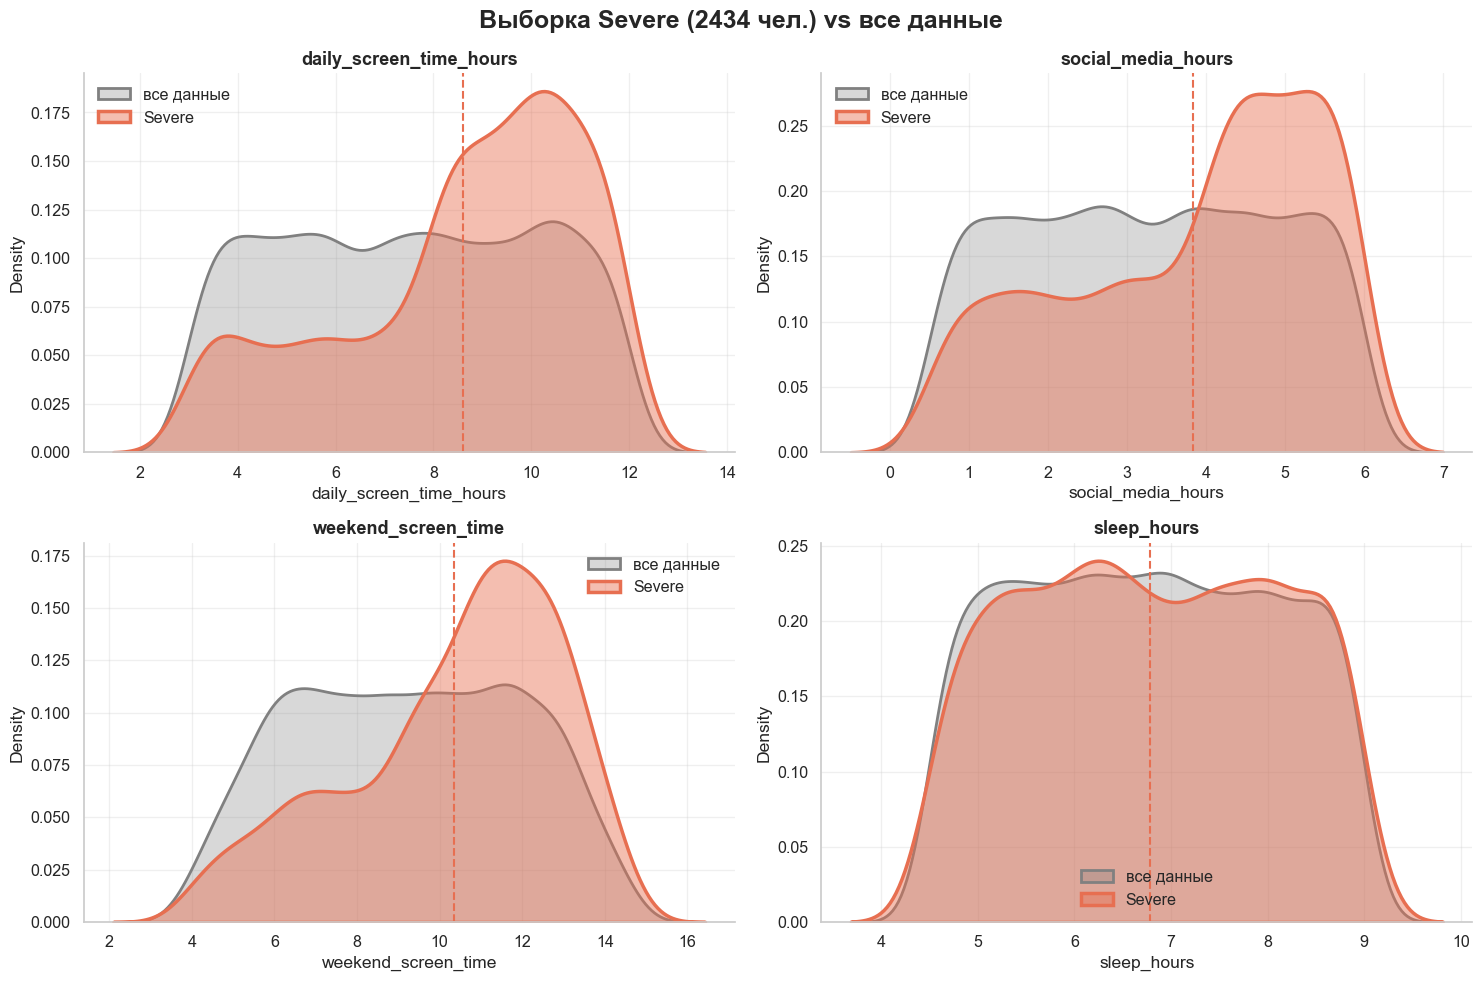

Средние в Severe vs во всех данных:


,Severe,Все
daily_screen_time_hours,8.60,7.50
social_media_hours,3.83,3.27
weekend_screen_time,10.36,9.24
sleep_hours,6.78,6.74


In [112]:
sev = df[df["addiction_level"] == "Severe"]
feats = ["daily_screen_time_hours", "social_media_hours", "weekend_screen_time", "sleep_hours"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f"Выборка Severe ({len(sev)} чел.) vs все данные", fontsize=18, fontweight="bold")

for ax, f in zip(axes.flat, feats):
    sns.kdeplot(df[f], fill=True, alpha=.3, lw=2, color="gray", label="все данные", ax=ax)
    sns.kdeplot(sev[f], fill=True, alpha=.45, lw=2.5, color="#e76f51", label="Severe", ax=ax)
    ax.axvline(sev[f].mean(), color="#e76f51", ls="--", lw=1.5)
    ax.set_title(f)
    ax.legend(frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

print("Средние в Severe vs во всех данных:")
pd.DataFrame({"Severe": sev[feats].mean(), "Все": df[feats].mean()}).round(2)

## Сила (r) и значимость (p) связи с таргетом

Для каждого числового признака — корреляция с `addicted_label` и её p-value.
Важно различать **r** (сила) и **p** (значимость): на большой выборке даже r≈0 может быть «значимым».

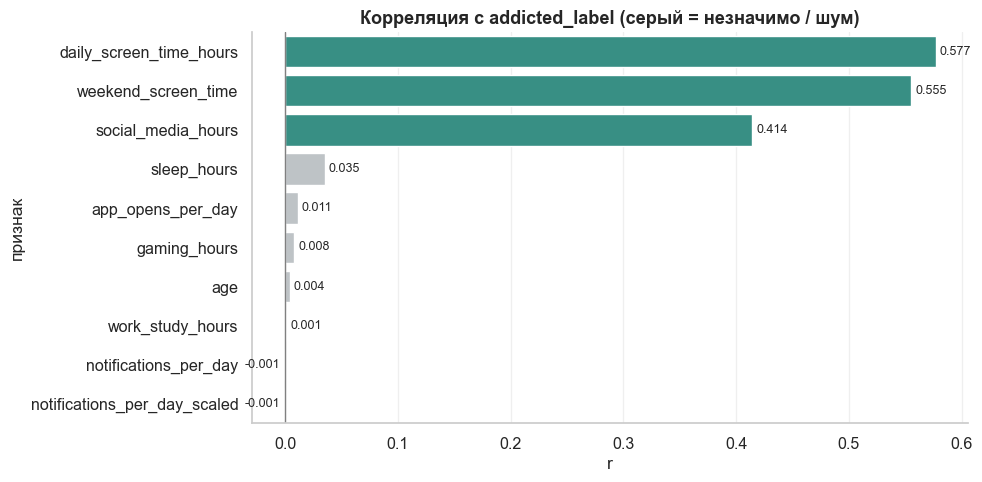

,признак,r,p_value,значим
0,daily_screen_time_hours,0.577,0.000000e+00,True
1,weekend_screen_time,0.555,0.000000e+00,True
2,social_media_hours,0.414,6.805309e-309,True
3,sleep_hours,0.035,2.108762e-03,True
4,app_opens_per_day,0.011,3.390316e-01,False
5,gaming_hours,0.008,4.624971e-01,False
6,age,0.004,7.147937e-01,False
7,work_study_hours,0.001,9.238824e-01,False
8,notifications_per_day,-0.001,9.544182e-01,False
9,notifications_per_day_scaled,-0.001,9.544182e-01,False


In [113]:
from scipy.stats import pearsonr

rows = []
for c in df.select_dtypes("number").drop(columns=["addicted_label"]).columns:
    r, p = pearsonr(df[c], df["addicted_label"])
    rows.append({"признак": c, "r": round(r, 3), "p_value": p, "значим": p < 0.05})
tbl = (pd.DataFrame(rows)
       .sort_values("r", key=lambda s: s.abs(), ascending=False)
       .reset_index(drop=True))

# серый = незначимо или |r| < 0.1 (т.е. шум)
colors = ["#2a9d8f" if (sig and abs(r) >= 0.1) else "#bdc3c7"
          for sig, r in zip(tbl["значим"], tbl["r"])]

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=tbl, x="r", y="признак", hue="признак",
                 palette=colors, legend=False)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", padding=3, fontsize=9)
ax.axvline(0, color="gray", lw=1)
ax.set_title("Корреляция с addicted_label (серый = незначимо / шум)")
sns.despine()
plt.tight_layout()
plt.show()

tbl

## p-value артефакта Берксона (Severe)

Считаем p-value связи `screen_time ↔ social_media` на всех данных и внутри Severe.
Цель — показать: ложная связь из отбора может быть **сильно значимой** по p, оставаясь артефактом.

In [ ]:
from scipy.stats import pearsonr

sev = df[df["addiction_level"] == "Severe"]
res = []
for name, d in [("Все данные", df), ("Severe", sev)]:
    r, p = pearsonr(d["daily_screen_time_hours"], d["social_media_hours"])
    res.append({"выборка": name, "n": len(d), "r": round(r, 3), "p_value": p,
                "значим": p < 0.05})
res = pd.DataFrame(res)
print(res.to_string(index=False))

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(data=res, x="выборка", y="r", hue="выборка",
                 palette={"Все данные": "#bdc3c7", "Severe": "#e76f51"}, legend=False)
ax.axhline(0, color="gray", lw=1)
for i, row in res.iterrows():
    off = 0.03 if row["r"] >= 0 else -0.06
    ax.text(i, row["r"] + off, f"r={row['r']:.2f}\np={row['p_value']:.1e}",
            ha="center", fontsize=9, fontweight="bold")
ax.set_title("screen_time ↔ social_media: все данные vs Severe")
ax.set_ylim(-0.55, 0.15)
sns.despine()
plt.tight_layout()
plt.show()

# 🏁 Итоговое заключение (day_6)

**Данные.** 7500 пользователей, 16 признаков. Дубликатов и выбросов нет. Пропуски только в `addiction_level` (819, 10.9%) — но бинарный таргет `addicted_label` заполнен полностью.

**Что определяет зависимость (`addicted_label`):**
- 🔴 `daily_screen_time_hours` — r = 0.58 (главный фактор)
- 🔴 `weekend_screen_time` — r = 0.56
- 🟠 `social_media_hours` — r = 0.41

**Что НЕ влияет** (связь ≈ 0):
- `gender` — распределение классов одинаковое у всех полов
- `stress_level` — Cramér's V = 0.01 (p = 0.87)
- `sleep_hours` — r ≈ 0 (сон не связан с использованием телефона)
- `age` — без связи

**Технические наблюдения:**
- `daily_screen_time` ↔ `weekend_screen_time` = 0.96 — почти дубликаты (риск мультиколлинеарности для модели).
- Таргет несбалансирован: 71% зависимых / 29% нет → смотреть precision/recall, а не только accuracy.

**Методологический урок:** корреляция внутри выборки `Severe` (screen_time ↔ social_media = −0.42) — это **парадокс Берксона (collider bias)**, артефакт отбора по следствию, а не реальная связь. Корреляции надо смотреть на всех данных.

**Вывод о датасете:** данные синтетические — связи заложены только в «ожидаемых» поведенческих парах, контекстные признаки (стресс, сон, пол, возраст) независимы. Подходит для тренировки EDA и классификации, но не для выводов о реальном поведении людей.

**Следующий шаг:** классификация `addicted_label` (логистическая регрессия даёт ~89% accuracy) с кодированием категорий и стандартизацией числовых признаков.